# Pipeline A — mid fusion (concat + conv) — results

**Presentation notebook — loads the trained artifacts and renders results; it does not train.** Produce them first via `training.ipynb` with `MODEL = "pipeline_a"`.

## 0. Setup

In [5]:
# Repo-root bootstrap — lets this notebook run from notebooks/ or the repo root.
import os, sys
from pathlib import Path
_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "globals.py").exists())
os.chdir(_ROOT)
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))
print("repo root:", _ROOT)

repo root: /home/leonardo/Desktop/AIRO/stereo-lidar-perception


In [6]:
import os
from pathlib import Path
import data  # noqa: F401
_REPO = Path(data.__file__).resolve().parent
os.environ.setdefault("PY123D_DATA_ROOT", str(_REPO / "data"))
os.environ.setdefault("KITTI360_DATA_ROOT", str(_REPO / "KITTI-360"))

import json
import matplotlib.pyplot as plt
import torch

import globals as G
import utils
from data import Py123dDataset, stereo_cache_root
from evaluation import CenterPointDecoder, load_report, print_ap_report
from network import StereoBEVConfig, build_detector
import igev_matcher  # noqa: F401

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL = "pipeline_a"
TAG = "_yolo26_igev"
CKPT = f"checkpoints/{MODEL}{TAG}.pt"
RESULTS = f"results/{MODEL}{TAG}.json"
HISTORY = f"results/{MODEL}{TAG}_history.json"
FIGDIR = Path("docs/img"); FIGDIR.mkdir(parents=True, exist_ok=True)
print("device:", DEVICE, "| model:", MODEL, "| classes:", G.CLASSES)

device: cuda | model: pipeline_a | classes: ('VEHICLE', 'PERSON', 'TWO_WHEELER', 'TRAFFIC_SIGN', 'TRAIN')


## 1. Training loss curves

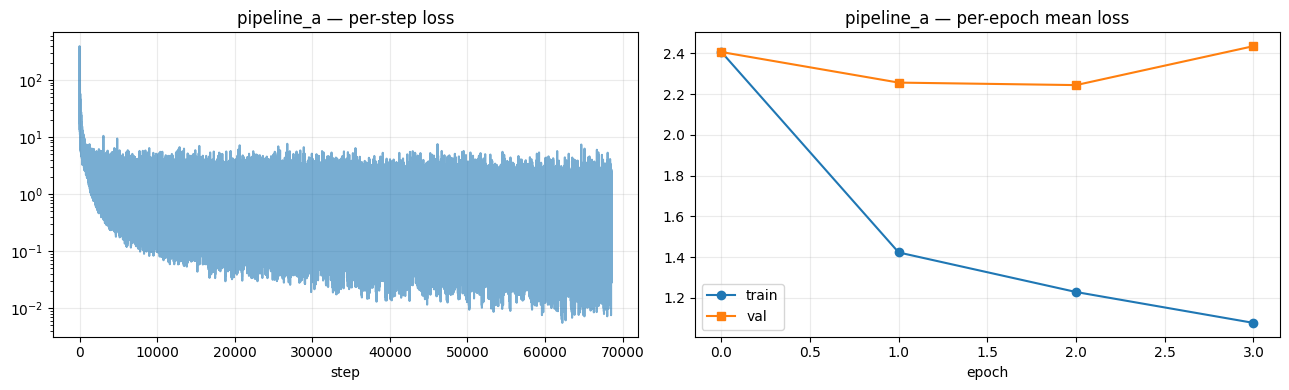

In [7]:
if not Path(HISTORY).exists():
    print(f"no {HISTORY} — (re)run training.ipynb §6 with the current notebook to "
          "save the loss curves (§6 calls save_history).")
else:
    history = json.loads(Path(HISTORY).read_text())
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(history["steps"], alpha=0.6); ax[0].set_yscale("log")
    ax[0].set_title(f"{MODEL} — per-step loss"); ax[0].set_xlabel("step"); ax[0].grid(alpha=0.25)
    ax[1].plot(history["train"], "o-", label="train"); ax[1].plot(history["val"], "s-", label="val")
    ax[1].set_title(f"{MODEL} — per-epoch mean loss"); ax[1].set_xlabel("epoch")
    ax[1].legend(); ax[1].grid(alpha=0.25)
    fig.tight_layout(); fig.savefig(FIGDIR / f"{MODEL}{TAG}_loss.png", dpi=90, bbox_inches="tight")
    plt.show()

## 2. Detection AP (per class · 0.5/1/2/4 m)

In [8]:
report = load_report(RESULTS)
print_ap_report(report)
print(f"\nHEADLINE  mAP {report['mAP']:.3f}  |  macro F1 {report['f1']:.3f} "
      f"@{report['op_threshold_m']:g} m  |  mean centre err {report['mean_error_m']:.3f} m")

class         AP@0.5  AP@1    AP@2    AP@4      mean   n_gt
-----------------------------------------------------------
VEHICLE       0.623   0.732   0.757   0.772   0.721  15975
PERSON        0.468   0.471   0.475   0.490   0.476  2911
TWO_WHEELER   0.349   0.387   0.397   0.410   0.386  2090
TRAFFIC_SIGN  0.274   0.280   0.291   0.313   0.290  1503
TRAIN         0.000   0.000   0.000   0.000   0.000  112

F1-optimal operating point @2 m (apply 'confidence >= score' at deployment):
class         prec    recall  F1      score   
----------------------------------------------
VEHICLE       0.720   0.718   0.719   0.322   
PERSON        0.541   0.481   0.510   0.203   
TWO_WHEELER   0.486   0.425   0.454   0.188   
TRAFFIC_SIGN  0.383   0.297   0.335   0.260   
TRAIN         0.000   0.000   0.000   nan     

mAP 0.374 | macro P 0.426 R 0.384 F1 0.403 @2 m | mean centre error (TP@2m) 0.345 m | 3026 frames

HEADLINE  mAP 0.374  |  macro F1 0.403 @2 m  |  mean centre err 0.345 m


## 3. Diagnostics — PR, F1-vs-confidence, confusion

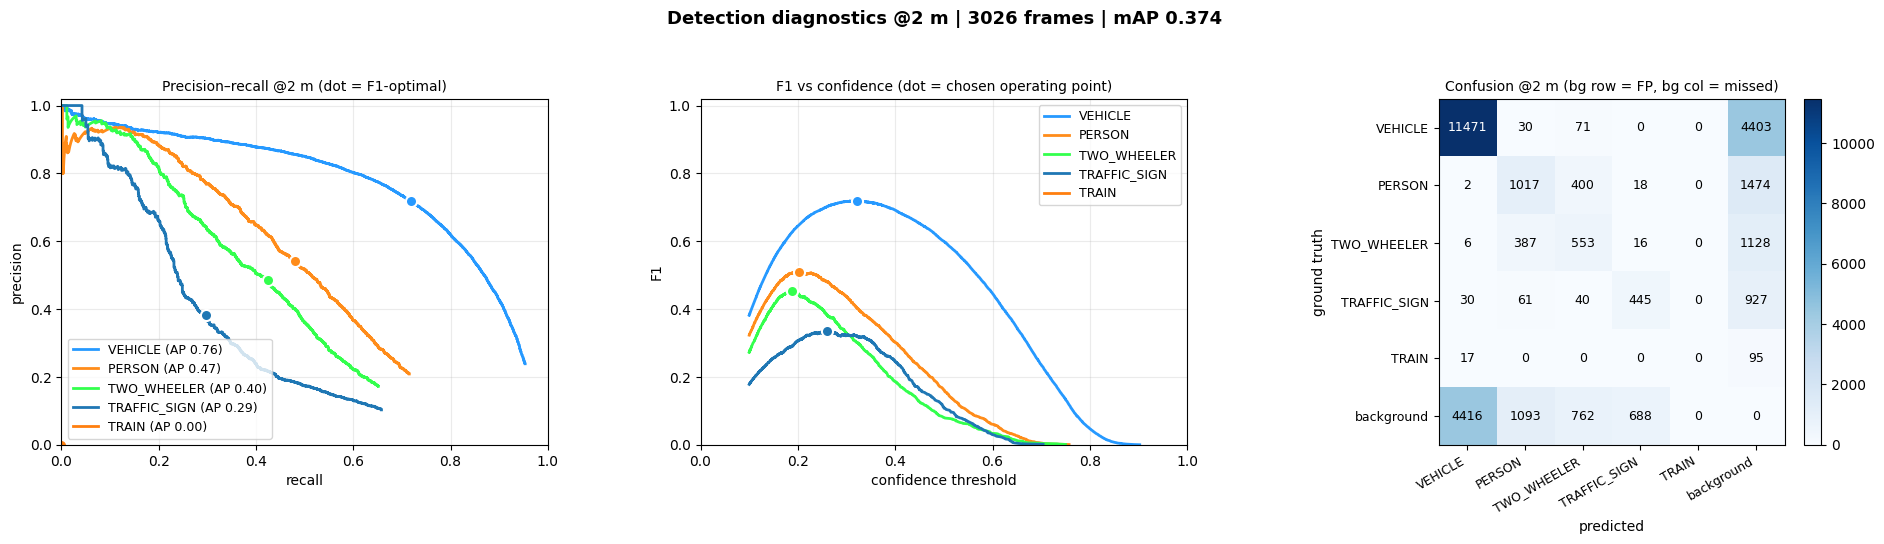

In [9]:
utils.visualize_evaluation(report, save_path=str(FIGDIR / f"{MODEL}{TAG}_diagnostics.png"))
utils.visualize_evaluation(report)

## 4. Qualitative — detections vs GT (BEV)

DEBUG: PY123D_DATA_ROOT resolved to /media/leonardo/Volume/stereo-lidar-data/data
DEBUG: found 1 scenes using filter SceneFilter(datasets=None, split_types=None, split_names=['kitti360_val'], log_names=None, has_map=None, map_has_z=None, map_locations=None, map_version=None, log_locations=None, log_version=None, scene_uuids=None, target_iteration_duration_s=None, future_duration_s=None, history_duration_s=None, timestamp_threshold_s=None, target_iteration_stride=None, future_num_iterations=None, history_num_iterations=None, iteration_threshold=None, required_scene_modalities=None, custom_filter_fns=None, num_chunks=None, chunk_idx=None, max_num_scenes=None, shuffle=False)


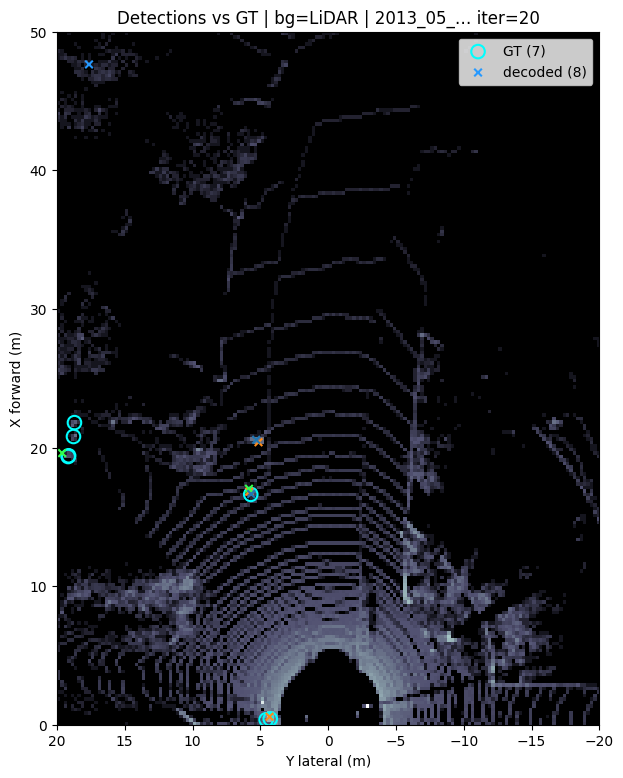

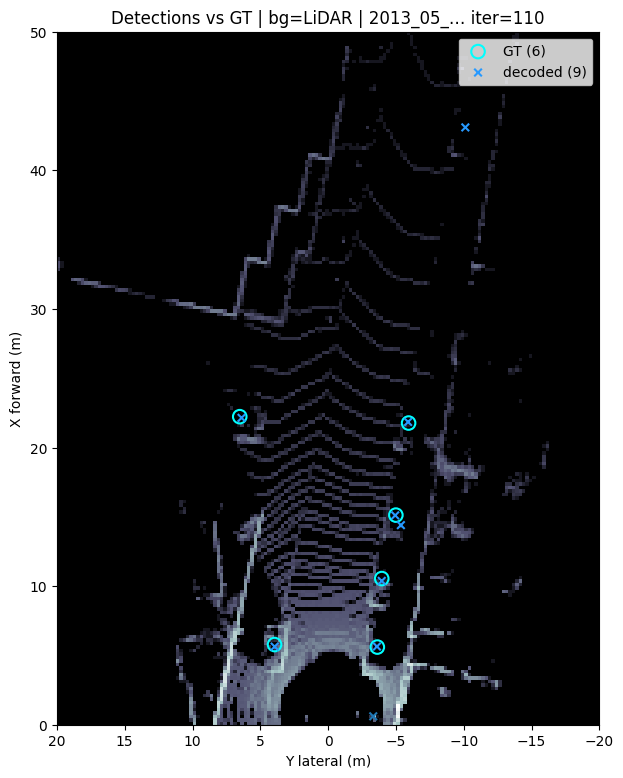

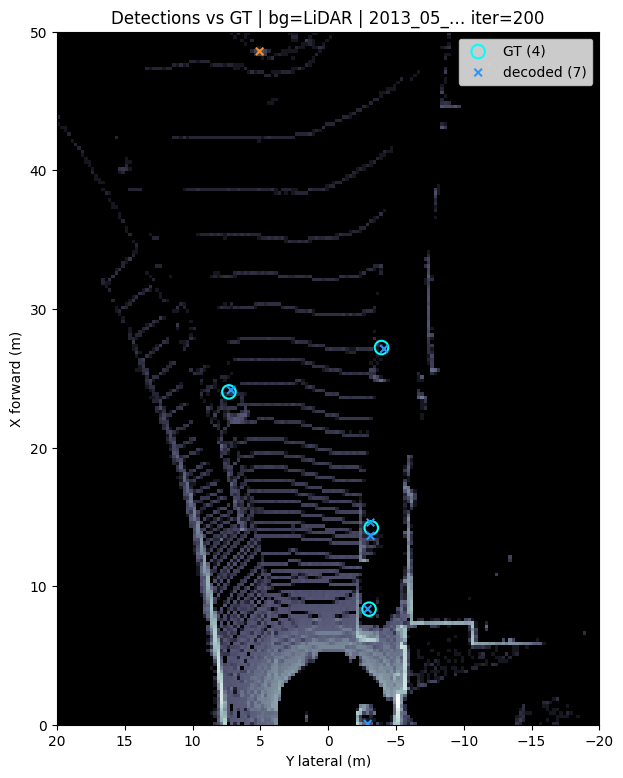

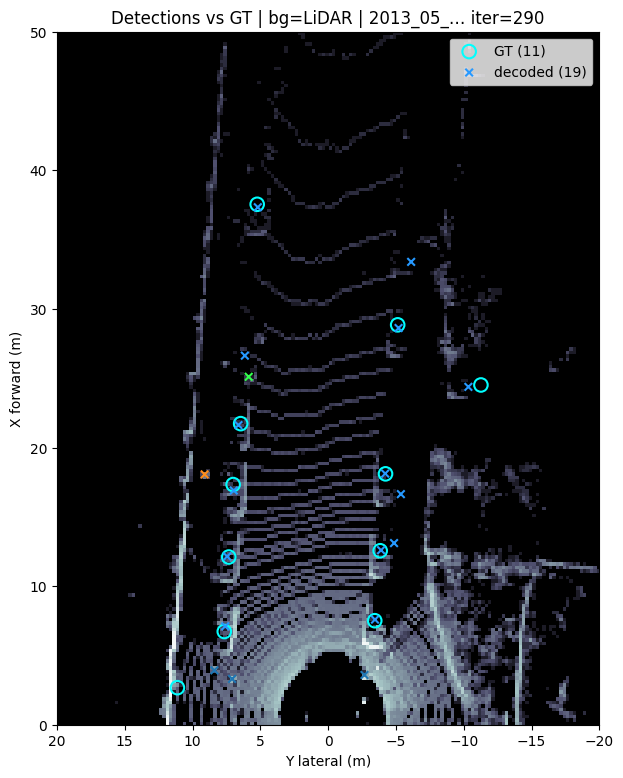

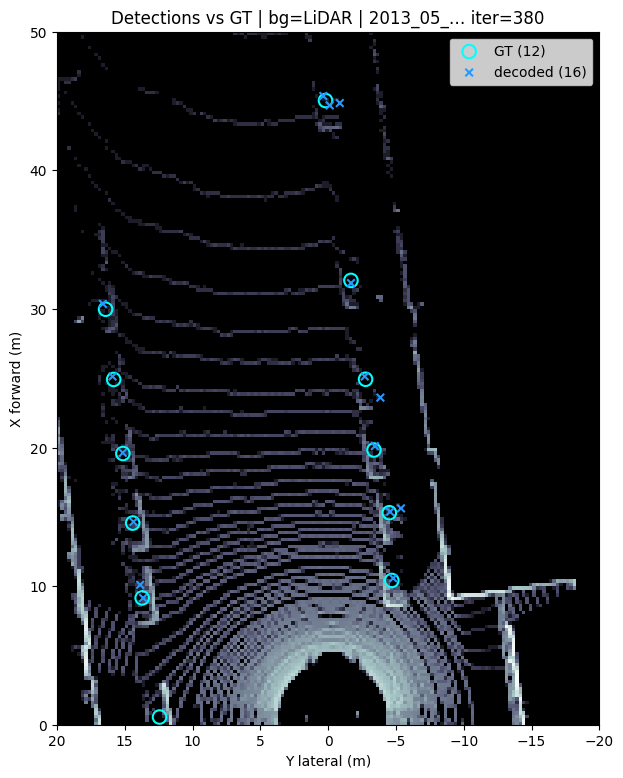

saved qualitative BEV frames -> docs/img


In [10]:
val_ds = Py123dDataset(split_names=["kitti360_val"]); val_frames = list(val_ds)
CACHE = stereo_cache_root(val_ds.data_root, matcher="igev")
stereo_cfg = StereoBEVConfig(img_backbone="yolo26", yolo_freeze=True)
model, input_fn = build_detector(MODEL, stereo_cache_root=CACHE, stereo_cfg=stereo_cfg)
model.load_state_dict(torch.load(CKPT, weights_only=True)["model"]); model.to(DEVICE).eval()
decoder = CenterPointDecoder(score_threshold=0.2)
for i, frame in enumerate(val_frames[20:400:90]):
    sample = frame.to_stereo_sample(load_images=False, point_mask=False)
    with torch.no_grad():
        out = model(input_fn(sample) if input_fn else sample, device=DEVICE)
    det = decoder(out["heatmap"].cpu(), out["offset"].cpu())[0]
    utils.visualize_detections(sample, det)                                   # inline
    utils.visualize_detections(sample, det,                                   # + save for slides
        save_path=str(FIGDIR / f"{MODEL}{TAG}_det_{i}.png"))
print("saved qualitative BEV frames ->", FIGDIR)

## 5. Stereo → BEV diagnostic (SEE vs PLACE)

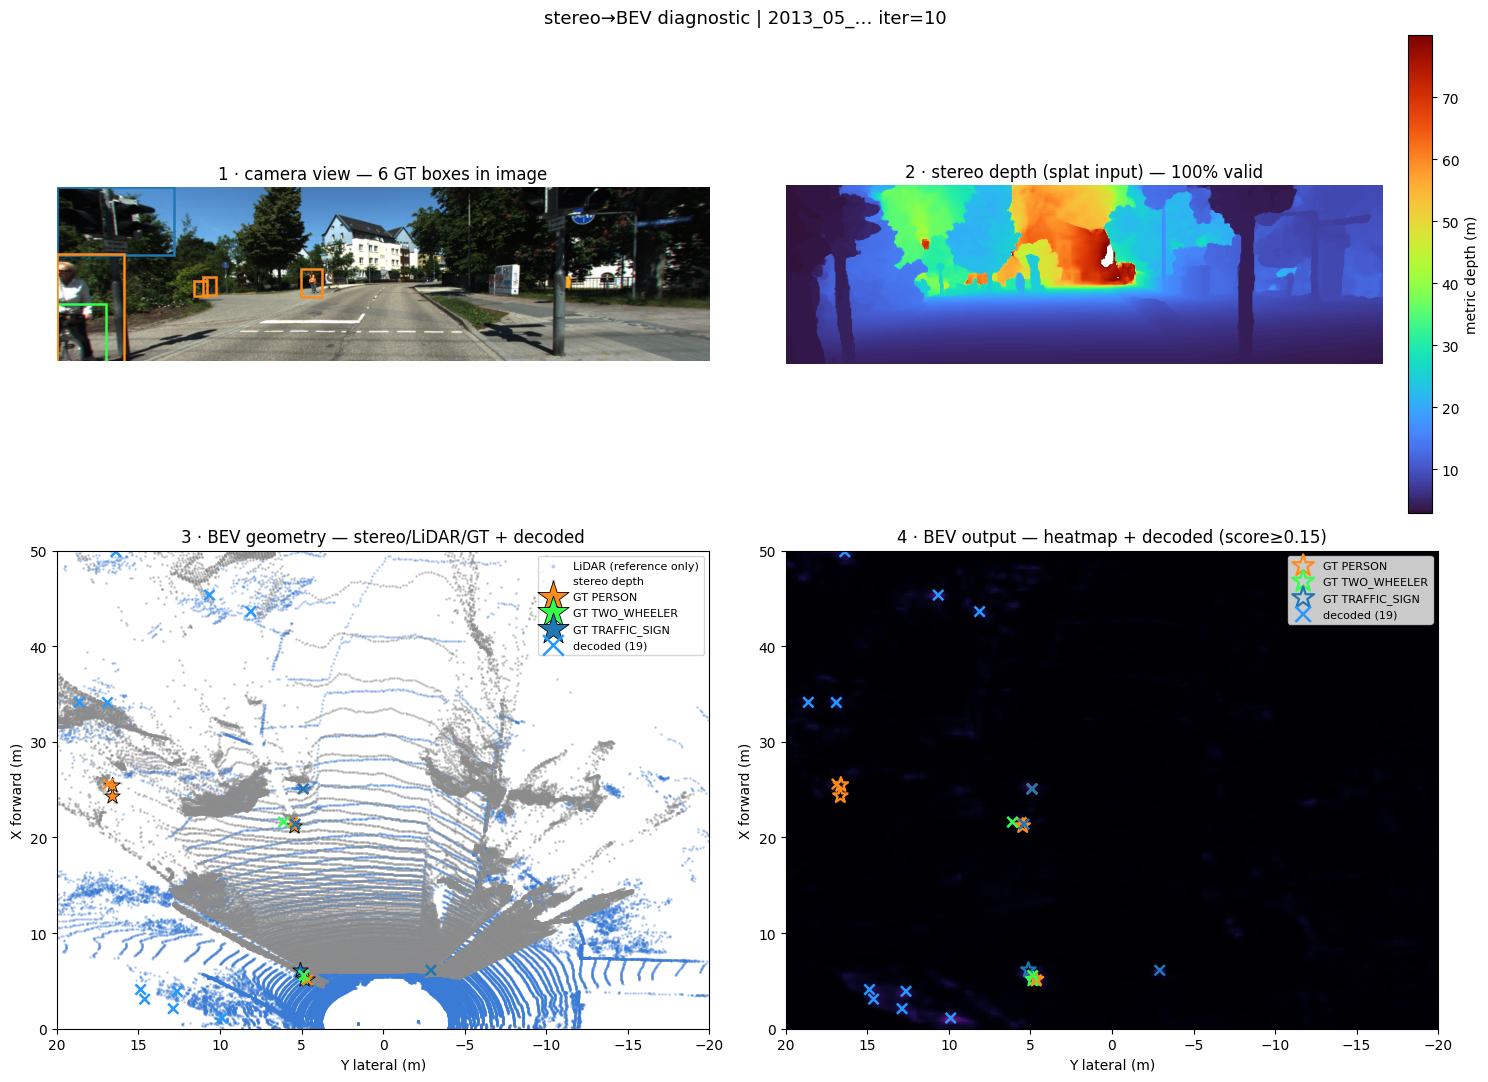

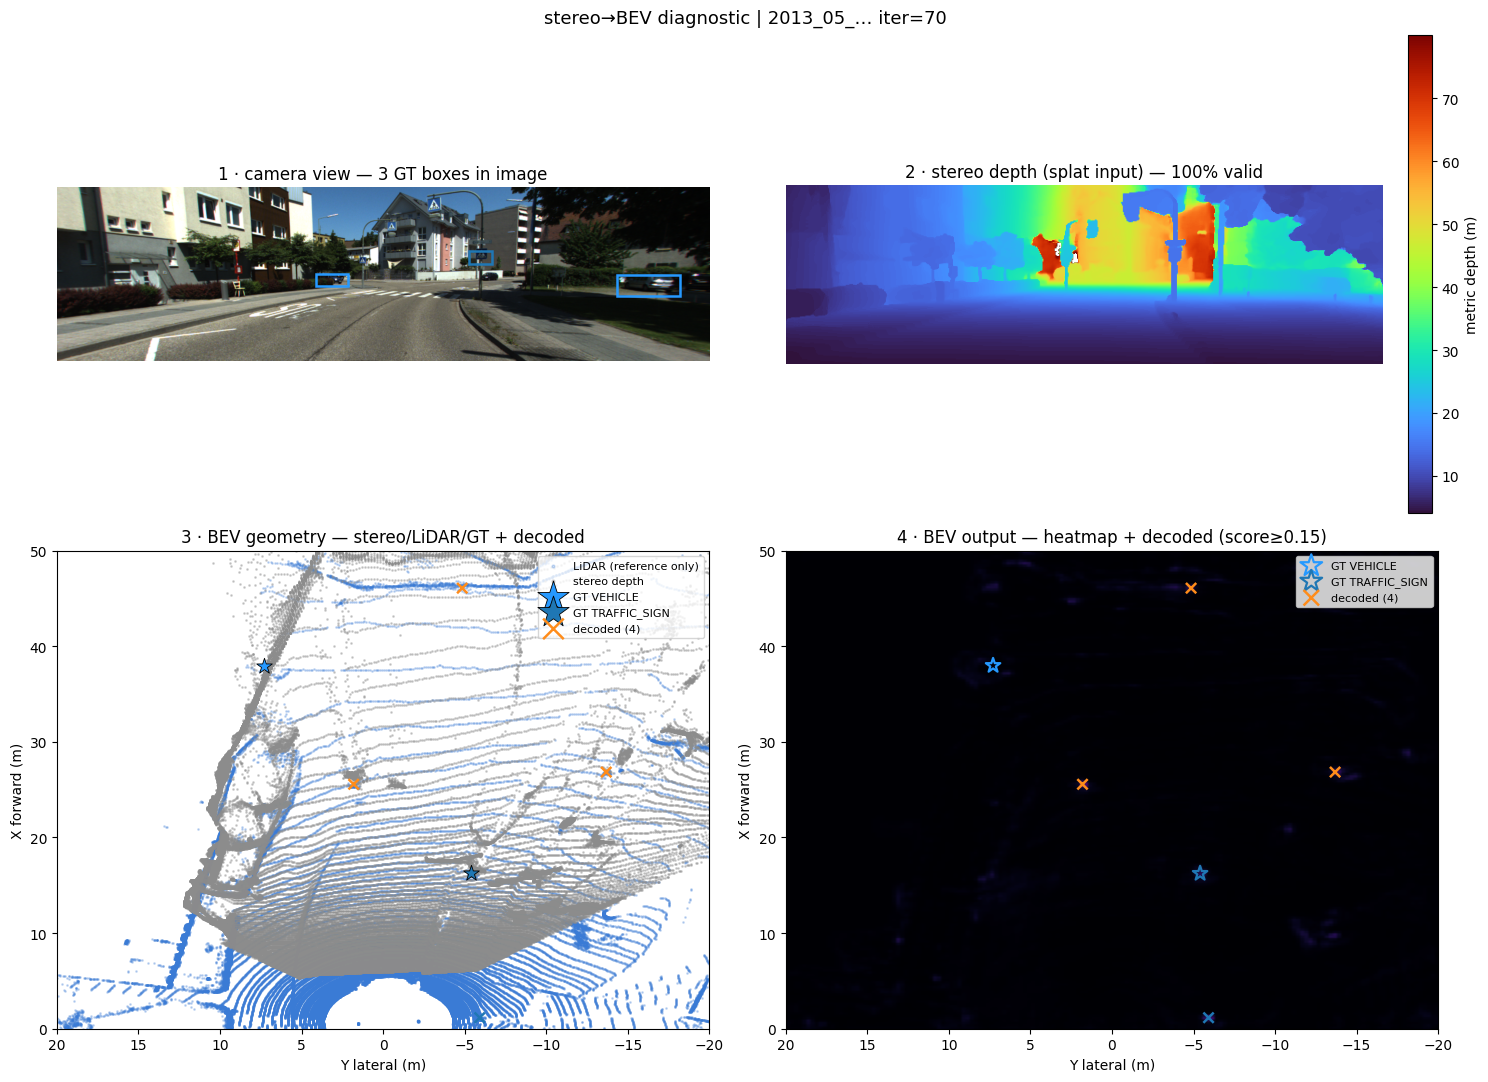

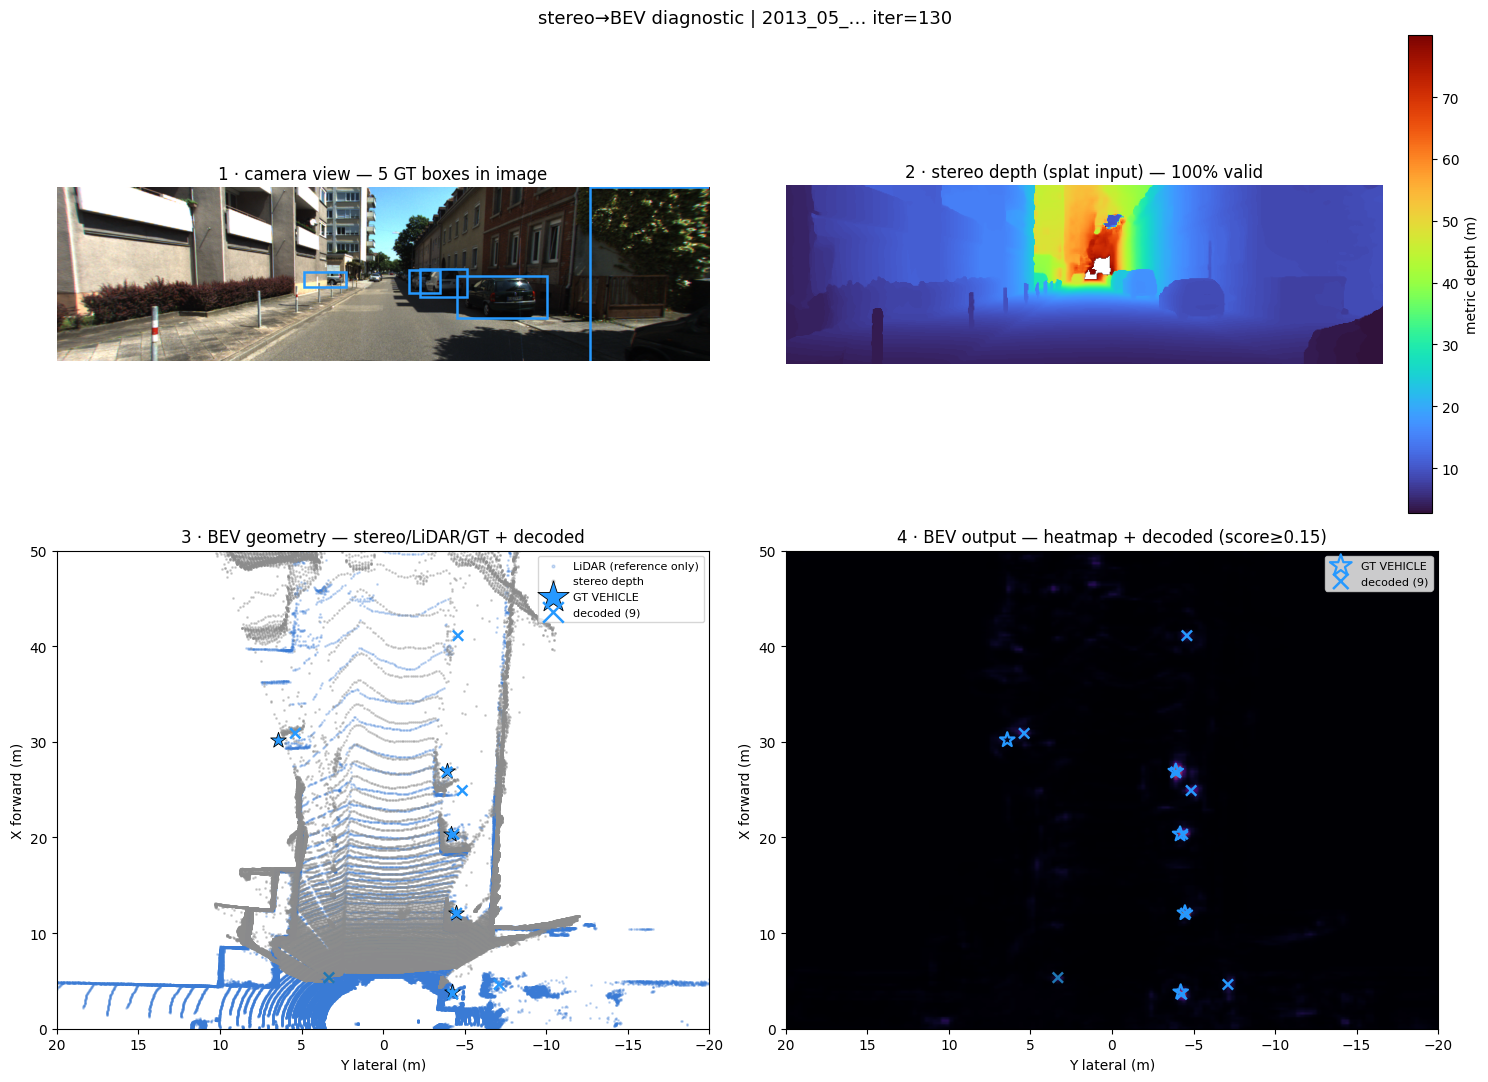

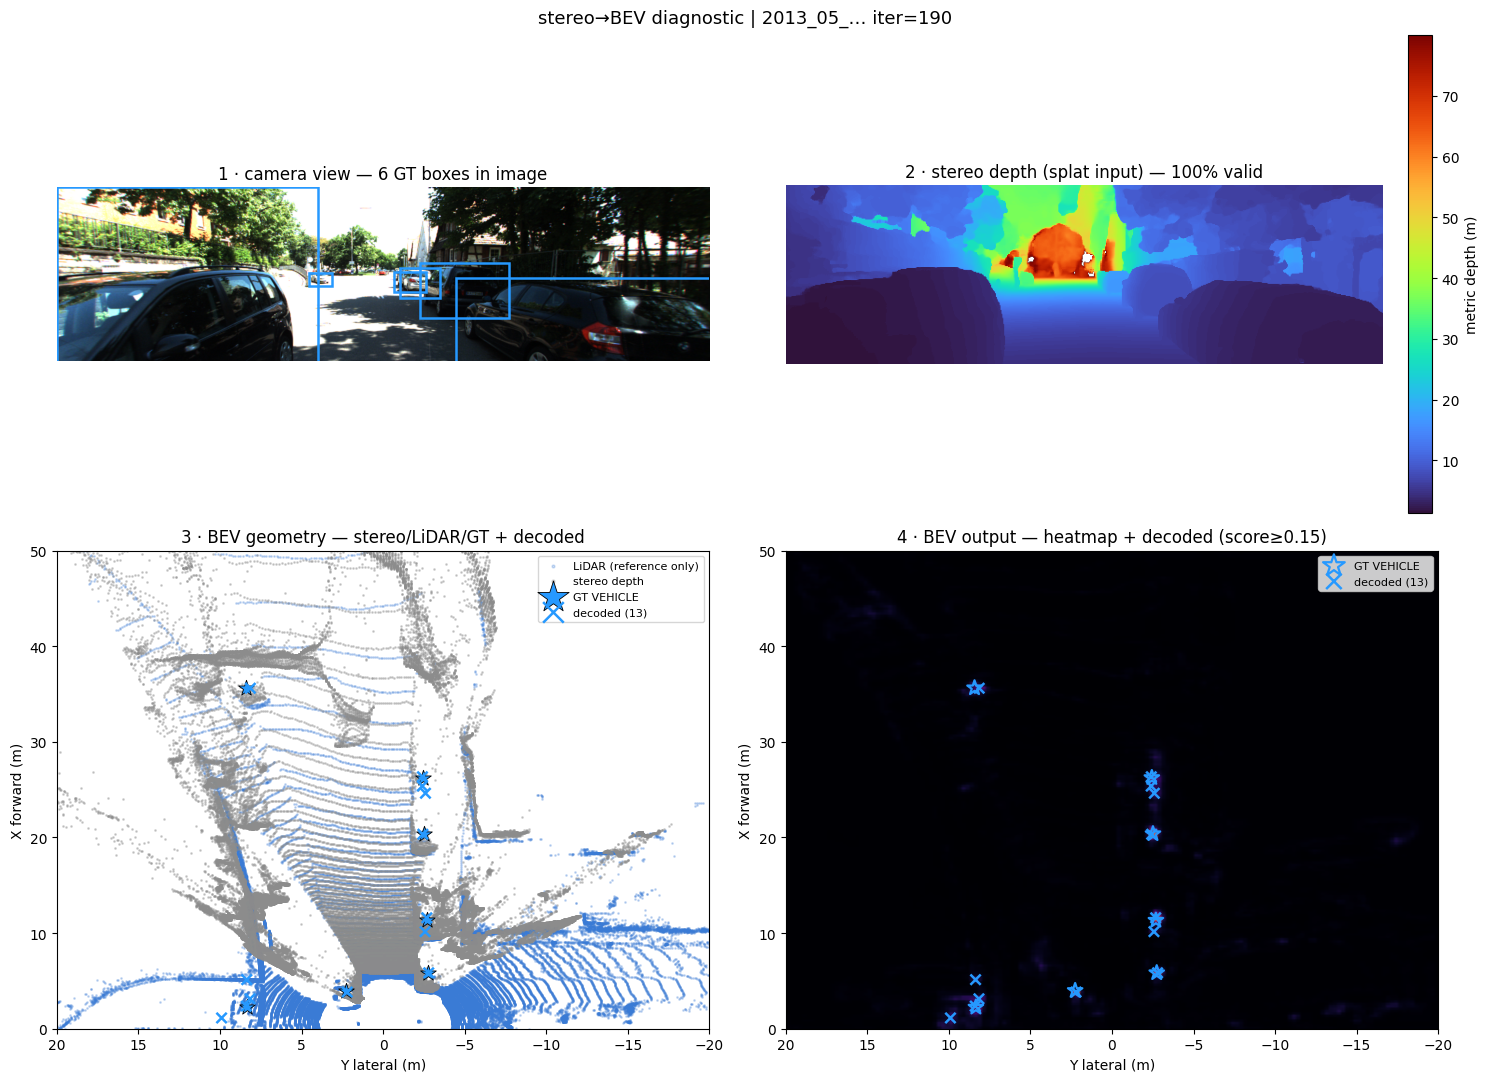

saved stereo->BEV diagnostics -> docs/img


In [11]:
# Stereo -> BEV diagnostic (the method's headline figure): split the camera path
# into SEEING vs PLACING. Panel 1 = image detections (does the net see it?),
# panel 3 = stereo depth, panel 4 = BEV output — an object seen but misplaced in
# BEV means the stereo depth put it in the wrong cell. Needs full samples (images).
for i, frame in enumerate(val_frames[10:200:60]):
    sample = frame.to_stereo_sample()  # full sample (load_images=True)
    utils.visualize_stereo_bev_diagnostic(model, sample, device=DEVICE,
                                          score_threshold=0.15)               # inline
    utils.visualize_stereo_bev_diagnostic(model, sample, device=DEVICE,       # + save
        score_threshold=0.15, save_path=str(FIGDIR / f"{MODEL}{TAG}_stereobev_{i}.png"))
print("saved stereo->BEV diagnostics ->", FIGDIR)

## 6. Branch contribution (drop-branch ablation)

In [12]:
from evaluation import evaluate_model
for drop in (None, "camera", "lidar"):
    model.drop_branch = drop
    rep = evaluate_model(model, val_frames, input_fn=input_fn, device=DEVICE)
    print(f"drop_branch={str(drop):<7} -> mAP {rep['mAP']:.3f}")
model.drop_branch = None

KeyboardInterrupt: 

---
*Figures in `docs/img/`. Cross-model comparison: `confronto.ipynb`.*